# Fairfax baseline prep notebook

This notebook prepares a small, reproducible Fairfax test workspace for the FAF5-based NIRD workflow.

## What this notebook does

1. Locates the project root using `config.json` and creates output folders.
2. Builds a Fairfax study-area polygon (with a small buffer).
3. Clips the FAF5 links to the study area and saves a local subset.
4. Creates a 17-node test package:
   - centroid node subset
   - synthetic 17×17 OD matrix
   - Class 50 connector subset
   - synthetic hazard attributes on connectors

## Why this is useful

It gives lightweight local test assets to validate script behavior before running large full-network jobs.

In [2]:
from pathlib import Path
import json
import geopandas as gpd
import pandas as pd

# Resolve project root robustly (works whether notebook cwd is repo root or sandbox/)
cwd = Path.cwd()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = next(
    (
        p
        for p in candidate_roots
        if (p / "config.json").exists() or (p / "configs.json").exists()
    ),
    None,
 )
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find config.json or configs.json from cwd={cwd}. Tried: {candidate_roots}"
    )

CONFIG_PATH = PROJECT_ROOT / "config.json"
if not CONFIG_PATH.exists():
    CONFIG_PATH = PROJECT_ROOT / "configs.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = json.load(f)

base_path = Path(cfg["paths"]["soge_clusters"])

sandbox_root = PROJECT_ROOT / "sandbox" / "fairfax_baseline"
out_inputs = sandbox_root / "inputs"
out_network_dir = out_inputs / "networks" / "faf5"
out_census_dir = out_inputs / "census_datasets"
out_study_area_dir = sandbox_root / "study_area"

for p in [out_network_dir, out_census_dir, out_study_area_dir]:
    p.mkdir(parents=True, exist_ok=True)

links_path = base_path / "networks" / "faf5" / "faf5_road_links.gpq"
od_path = base_path / "census_datasets" / "faf5_od_matrix.pq"

print(f"Project root: {PROJECT_ROOT}")
print(f"Using config: {CONFIG_PATH.name}")
print(f"Base data root: {base_path}")
print(f"Sandbox output root: {sandbox_root}")
print(f"Road links exists: {links_path.exists()} | {links_path}")
print(f"OD matrix exists: {od_path.exists()} | {od_path}")

Project root: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean
Using config: configs.json
Base data root: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline
Sandbox output root: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline
Road links exists: False | c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\networks\faf5\faf5_road_links.gpq
OD matrix exists: False | c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\census_datasets\faf5_od_matrix.pq


## Setup and path resolution

This cell:

- imports core libraries (`pathlib`, `json`, `geopandas`, `pandas`)
- searches upward from the current working directory to find `config.json`
- reads `paths.soge_clusters` as the base data location
- creates the local sandbox folders used by later cells
- checks whether baseline FAF5 links and OD inputs already exist

Use the printed paths to confirm the notebook is pointing at the right workspace.

In [3]:
from shapely.geometry import box

# Approximate Fairfax, VA bounding box in EPSG:4326
# (west, south, east, north)
fairfax_bbox = box(-77.60, 38.68, -76.95, 39.08)
study_area = gpd.GeoDataFrame({"name": ["fairfax_va_bbox"]}, geometry=[fairfax_bbox], crs="EPSG:4326")

# Buffer by 5 km for edge continuity near boundary
study_area = study_area.to_crs("EPSG:3857")
study_area["geometry"] = study_area.geometry.buffer(5000)
study_area = study_area.to_crs("EPSG:4326")

study_geojson = out_study_area_dir / "fairfax_study_area.geojson"
study_gpkg = out_study_area_dir / "fairfax_study_area.gpkg"
study_area.to_file(study_geojson, driver="GeoJSON")
study_area.to_file(study_gpkg, driver="GPKG")

print(f"Saved study area: {study_geojson}")
print(f"Saved study area: {study_gpkg}")
study_area

Saved study area: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\study_area\fairfax_study_area.geojson
Saved study area: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\study_area\fairfax_study_area.gpkg


,name,geometry
0,fairfax_va_bbox,"POLYGON ((-76.95 38.64493, -77.6 38.64493, -77..."


## Build Fairfax study-area boundary

This cell creates a simple Fairfax-area bounding polygon in WGS84 (`EPSG:4326`), then buffers it by 5 km (in a projected CRS) to reduce edge effects during clipping.

Outputs written:

- `study_area/fairfax_study_area.geojson`
- `study_area/fairfax_study_area.gpkg`

The buffered boundary is used as the clip mask for network extraction.

In [5]:
# Try configured parquet first; fallback to FAF5 source geodatabase links
if links_path.exists():
    links = gpd.read_parquet(links_path)
    print(f"Loaded links from parquet: {links_path}")
else:
    fallback_gdb = Path(
        r"C:\Users\alimu\Desktop\Github\FAF5_Model_Highway_Network\Networks\Geodatabase Format\FAF5Network.gdb"
    )
    if not fallback_gdb.exists():
        raise FileNotFoundError(
            f"Missing links parquet and fallback geodatabase. Checked: {links_path} and {fallback_gdb}"
        )
    links = gpd.read_file(fallback_gdb, layer="FAF5_Links")
    print(f"Loaded links from fallback gdb: {fallback_gdb}")

if links.crs != study_area.crs:
    clip_poly = study_area.to_crs(links.crs)
else:
    clip_poly = study_area

orig_count = len(links)
clipped_links = gpd.sjoin(links, clip_poly, how="inner", predicate="intersects")
clipped_links = clipped_links[links.columns].copy()
clipped_links = clipped_links.reset_index(drop=True)

out_links = out_network_dir / "faf5_road_links.gpq"
clipped_links.to_parquet(out_links)

print(f"Original links: {orig_count:,}")
print(f"Clipped links: {len(clipped_links):,}")
print(f"Saved: {out_links}")
clipped_links.head(3)

Loaded links from fallback gdb: C:\Users\alimu\Desktop\Github\FAF5_Model_Highway_Network\Networks\Geodatabase Format\FAF5Network.gdb
Original links: 487,394
Clipped links: 4,541
Saved: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\networks\faf5\faf5_road_links.gpq


,ID,LENGTH,DIR,DATA,VERSION,Class,Class_Description,Road_Name,Sign_Rte,Rte_Type,...,AdjustSpeed,AdjustReason,AB_FinalSpeed,BA_FinalSpeed,AB_CombinedSpeed,BA_CombinedSpeed,AB_FreeFlowTime,BA_FreeFlowTime,SHAPE_Length,geometry
0,1414145,0.956965,1,912847,V2021.05,21.0,System Ramp,I 395 SB to I 95 NB,NaN,NaN,...,NaN,NaN,43.0,43.0,43.0,43.0,1.335299,1.335299,0.016594,"MULTILINESTRING ((-77.17163 38.79539, -77.1716..."
1,1414146,0.414598,1,913187,V2021.05,11.0,Interstate Highway,I 395,I 395,I,...,NaN,NaN,49.5,49.5,49.5,49.5,0.502543,0.502543,0.006727,"MULTILINESTRING ((-77.17054 38.79559, -77.1705..."
2,1414147,0.312046,1,1127748,V2021.05,14.0,Arterial or Major Collector,FRANCONIA SPRINGFIELD PKWY,VA 286,S,...,NaN,NaN,43.0,43.0,43.0,43.0,0.435413,0.435413,0.005655,"MULTILINESTRING ((-77.16748 38.76803, -77.1620..."


## Clip FAF5 road links to the study area

This cell:

- loads full FAF5 links from the configured base path
- aligns CRS with the study-area geometry
- performs a spatial intersect join to keep only Fairfax-area links
- saves the clipped subset to:
  - `inputs/networks/faf5/faf5_road_links.gpq`

Use the original/clipped row counts as a quick sanity check for clipping behavior.

## Build the 17-node toy OD matrix

This chunk creates the small workflow-test demand table.

### What it does

1. Selects 17 Fairfax-area centroid nodes from the FAF5 node layer.
2. Builds a synthetic 17×17 OD matrix using a simple distance-decay rule.
3. Saves the OD outputs to the toy input folder.
4. Extracts Class 50 connector links for the same area so they can be reused by the hazard chunk.

### Files written

- `fairfax_centroid_nodes_17.gpkg`
- `faf5_od_matrix_17x17_test.pq`
- `faf5_od_matrix_17x17_test.csv`
- `fairfax_class50_connectors.gpkg`

The next chunk turns those connectors into base/low/high hazard layers.

In [8]:
import numpy as np

# --- Inputs ---
faf5_gdb_path = Path(r"C:\Users\alimu\Desktop\Github\FAF5_Model_Highway_Network\Networks\Geodatabase Format\FAF5Network.gdb")
if not faf5_gdb_path.exists():
    raise FileNotFoundError(f"FAF5 source geodatabase not found: {faf5_gdb_path}")

orig_nodes_layer = "FAF5_Nodes"
orig_links_layer = "FAF5_Links"

out_test_dir = sandbox_root / "inputs" / "test_17node"
out_test_dir.mkdir(parents=True, exist_ok=True)

# --- Read original FAF5 nodes + links ---
orig_nodes = gpd.read_file(faf5_gdb_path, layer=orig_nodes_layer)
orig_links = gpd.read_file(faf5_gdb_path, layer=orig_links_layer)

# Ensure CRS alignment with study_area
study_poly = study_area.copy()
if study_poly.crs != orig_nodes.crs:
    study_poly = study_poly.to_crs(orig_nodes.crs)

# --- Extract centroid nodes in/near study area ---
node_id_col = next((c for c in ["ID", "node_id", "NodeID", "id"] if c in orig_nodes.columns), None)
if node_id_col is None:
    raise KeyError(f"No node ID column found in FAF5_Nodes. Columns={list(orig_nodes.columns)}")

if "Centroid" not in orig_nodes.columns:
    raise KeyError("FAF5_Nodes does not contain 'Centroid' column")

orig_centroids = orig_nodes[orig_nodes["Centroid"] == 1].copy()
centroids_17 = gpd.sjoin(orig_centroids, study_poly[["geometry"]], how="inner", predicate="intersects").copy()
centroids_17 = centroids_17.sort_values(by=[node_id_col]).drop_duplicates(subset=[node_id_col]).copy()

# If strict intersection gives <17, expand with nearest centroids to study area (projected CRS for distance)
if len(centroids_17) < 17:
    missing_n = 17 - len(centroids_17)

    study_poly_m = study_poly.to_crs("EPSG:3857")
    study_union_m = study_poly_m.geometry.union_all()

    extras = orig_centroids[~orig_centroids[node_id_col].isin(centroids_17[node_id_col])].copy()
    extras_m = extras.to_crs("EPSG:3857")
    extras["_dist_m"] = extras_m.geometry.distance(study_union_m)
    extras = extras.sort_values("_dist_m").head(missing_n)

    centroids_17 = pd.concat([centroids_17, extras], ignore_index=True)

centroids_17 = centroids_17.sort_values(by=[node_id_col]).drop_duplicates(subset=[node_id_col]).head(17).copy()

if len(centroids_17) != 17:
    raise ValueError(f"Could not assemble 17 centroid nodes; got {len(centroids_17)}")

centroid_node_ids = centroids_17[node_id_col].astype(int).tolist()

# Save centroid node subset
centroids_17_out = out_test_dir / "fairfax_centroid_nodes_17.gpkg"
centroids_17.to_file(centroids_17_out, layer="centroid_nodes_17", driver="GPKG")

# --- Build 17x17 OD matrix (synthetic test demand) ---
c17_m = centroids_17.to_crs("EPSG:3857").copy()
coords = c17_m.set_index(node_id_col).geometry

rows = []
for o in centroid_node_ids:
    for d in centroid_node_ids:
        dist_km = coords.loc[o].distance(coords.loc[d]) / 1000.0
        if o == d:
            car21 = 220
        else:
            # Smooth distance-decay rule: closer pairs get more demand than distant pairs
            car21 = int(max(5, round(140 / (1 + 0.12 * dist_km))))
        tonnage = (car21 * 20.0 * 365.0) / 1000.0
        rows.append({
            "origin_node": int(o),
            "destination_node": int(d),
            "Car21": int(car21),
            "tonnage": float(tonnage)
        })

od_17 = pd.DataFrame(rows)
od_17_out_pq = out_test_dir / "faf5_od_matrix_17x17_test.pq"
od_17_out_csv = out_test_dir / "faf5_od_matrix_17x17_test.csv"
od_17.to_parquet(od_17_out_pq)
od_17.to_csv(od_17_out_csv, index=False)

# --- Extract Class==50 centroid connectors in study area ---
if "Class" not in orig_links.columns:
    raise KeyError("FAF5_Links does not contain 'Class' column")

connectors = orig_links[orig_links["Class"] == 50].copy()
if connectors.crs != study_poly.crs:
    connectors = connectors.to_crs(study_poly.crs)

connectors_in_area = gpd.sjoin(connectors, study_poly[["geometry"]], how="inner", predicate="intersects").copy()

connectors_out = out_test_dir / "fairfax_class50_connectors.gpkg"
connectors_in_area.to_file(connectors_out, layer="class50_connectors", driver="GPKG")

print("17-node OD test assets created:")
print(f"- Centroid nodes (17): {centroids_17_out}")
print(f"- OD matrix (17x17={len(od_17)} rows): {od_17_out_pq}")
print(f"- OD CSV: {od_17_out_csv}")
print(f"- Class 50 connectors in area: {connectors_out} | rows={len(connectors_in_area)}")
print(f"\nTotal Car21 flow in 17x17 matrix: {od_17['Car21'].sum():,}")
od_17.head(3)

17-node OD test assets created:
- Centroid nodes (17): c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\fairfax_centroid_nodes_17.gpkg
- OD matrix (17x17=289 rows): c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\faf5_od_matrix_17x17_test.pq
- OD CSV: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\faf5_od_matrix_17x17_test.csv
- Class 50 connectors in area: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\fairfax_class50_connectors.gpkg | rows=17

Total Car21 flow in 17x17 matrix: 13,772


,origin_node,destination_node,Car21,tonnage
0,1627414,1627414,220,1606.0
1,1627414,1627424,58,423.4
2,1627414,1627907,80,584.0


## Create the toy hazard rasters

This chunk converts the toy hazard into real raster files.

### What it does

- builds a 10 m grid in the same projected CRS used by the workflow (`EPSG:2163`)
- assigns each grid cell a synthetic inundation depth in meters
- writes three GeoTIFFs with the same spatial pattern but different severity:
  - `base`
  - `low` = `0.7 × base`
  - `high` = `1.5 × base`

### Why this is the right toy format

Script 2 expects a raster hazard layer, not a line layer. Each raster cell stores depth, which is much easier to interpret and matches the real workflow structure.

In [12]:
import numpy as np
import rasterio
from rasterio.transform import from_origin

# --- Build base, low, and high hazard rasters ---
raster_crs = "EPSG:2163"
cell_size = 10  # 10 m resolution
hazard_extent = connectors_in_area.to_crs(raster_crs)
if hazard_extent.empty:
    raise ValueError("No connector features available to define the toy hazard raster extent")

minx, miny, maxx, maxy = hazard_extent.total_bounds
pad_m = 500
minx -= pad_m
miny -= pad_m
maxx += pad_m
maxy += pad_m

width = int(np.ceil((maxx - minx) / cell_size))
height = int(np.ceil((maxy - miny) / cell_size))
transform = from_origin(minx, maxy, cell_size, cell_size)

x_coords = minx + (np.arange(width) + 0.5) * cell_size
y_coords = maxy - (np.arange(height) + 0.5) * cell_size
xx, yy = np.meshgrid(x_coords, y_coords)

# A simple, easy-to-explain synthetic flood surface: deeper toward the southeast
x_norm = (xx - minx) / (maxx - minx)
y_norm = (yy - miny) / (maxy - miny)
depth_base = 0.05 + 0.95 * (0.65 * x_norm + 0.35 * (1 - y_norm))
depth_base = np.clip(depth_base, 0.0, 1.2).astype("float32")
depth_low = np.clip(depth_base * 0.7, 0.0, 1.2).astype("float32")
depth_high = np.clip(depth_base * 1.5, 0.0, 1.2).astype("float32")

base_tif = out_test_dir / "fairfax_hazard_class50_17node_base.tif"
low_tif = out_test_dir / "fairfax_hazard_class50_17node_low.tif"
high_tif = out_test_dir / "fairfax_hazard_class50_17node_high.tif"
compat_tif = out_test_dir / "fairfax_hazard_class50_17node.tif"

profile = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "dtype": "float32",
    "crs": raster_crs,
    "transform": transform,
    "nodata": 0.0,
    "compress": "deflate",
}

for path, array in [
    (base_tif, depth_base),
    (low_tif, depth_low),
    (high_tif, depth_high),
    (compat_tif, depth_base),
]:
    with rasterio.open(path, "w", **profile) as dataset:
        dataset.write(array, 1)

print("Hazard rasters created:")
print(f"- Base hazard: {base_tif}")
print(f"- Low hazard: {low_tif}")
print(f"- High hazard: {high_tif}")
print(f"- Compatibility base hazard: {compat_tif}")
print(f"\nRaster size: {width} x {height} cells at {cell_size} m resolution")
print(f"Base hazard depth range (m): {depth_base.min():.3f} - {depth_base.max():.3f}")
print(f"Low hazard depth range (m): {depth_low.min():.3f} - {depth_low.max():.3f}")
print(f"High hazard depth range (m): {depth_high.min():.3f} - {depth_high.max():.3f}")
print("Interpretation: low = 0.7x base; high = 1.5x base.")

Hazard rasters created:
- Base hazard: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\fairfax_hazard_class50_17node_base.tif
- Low hazard: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\fairfax_hazard_class50_17node_low.tif
- High hazard: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\fairfax_hazard_class50_17node_high.tif
- Compatibility base hazard: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_baseline\inputs\test_17node\fairfax_hazard_class50_17node.tif

Raster size: 4814 x 5280 cells at 10 m resolution
Base hazard depth range (m): 0.050 - 1.000
Low hazard depth range (m): 0.035 - 0.700
High hazard depth range (m): 0.075 - 1.200
Interpretation: low = 0.7x base; high = 1.5x base.


## Visualize the toy hazard rasters

This preview checks that the three GeoTIFFs preserve the same spatial pattern while changing only in intensity.

Use it to confirm:

- the depth field is raster-based, not vector-based
- the cell values look like inundation depths in meters
- the low/base/high layers are scaled versions of the same surface

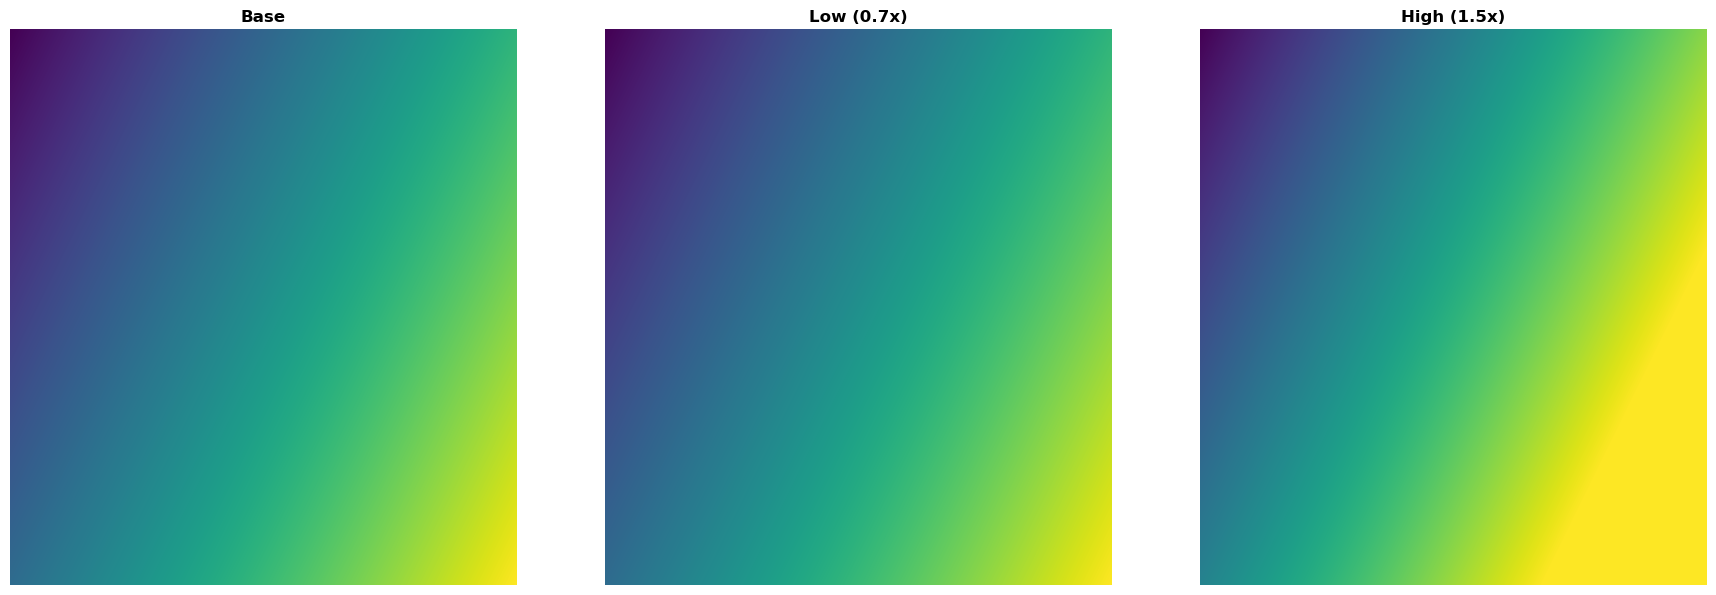

In [13]:
import matplotlib.pyplot as plt
from rasterio.plot import show

plot_layers = [
    ("Base", base_tif),
    ("Low (0.7x)", low_tif),
    ("High (1.5x)", high_tif),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for axis, (title, tif_path) in zip(axes, plot_layers):
    with rasterio.open(tif_path) as dataset:
        show(dataset, ax=axis, cmap="viridis", title=title)
    axis.set_axis_off()

plt.tight_layout()
plt.show()